# Example of Gene Expression Copy Number Correction

May 30, 2024

## Goal:
Apply the copy number correction procedure described in the toy replication notebook. This time applied to genes

**Notes:**
Gene counts will be taken from the previously computed deconvolved f matrices. Replication profiles have been previously computed for all 10k windows. Gene's are assigned to specific 10k windows.

Normalization will be based on genome only. In that the replication profiles will be subset to only include the genes. This is for simplicity because we do not have deconvolved profiles for intergenic regions at the moment.

**Procedure:**
1. Collect the total read counts for all genes for all timepoints into a matrix of size
    (# of genes x deconvolved timepoints) ~ 5500x187 
2. Collect the replication profile for these genes: Look up the 10k bin for each gene into a replication profile matrix of the same dimension:
    (# of genes x deconvolved timepoints) ~ 5500x187
3. Perform copy number correction on the read counts to retrieve a new read count matrix:
    (# of genes x deconvolved timepoints) ~ 5500x187
    
**Expectation:**
- For each gene there will be a sharp decrease in reads at replication time, maybe it will be less dramatic if the size of the genome and number of genes replicating dampens the replication affect on the read count.
- When plotting a gene with unchanging expression: This jump in read count will be the most clear. Plot some control genes in which the gene expression did not appear to change prior to copy number normalization.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


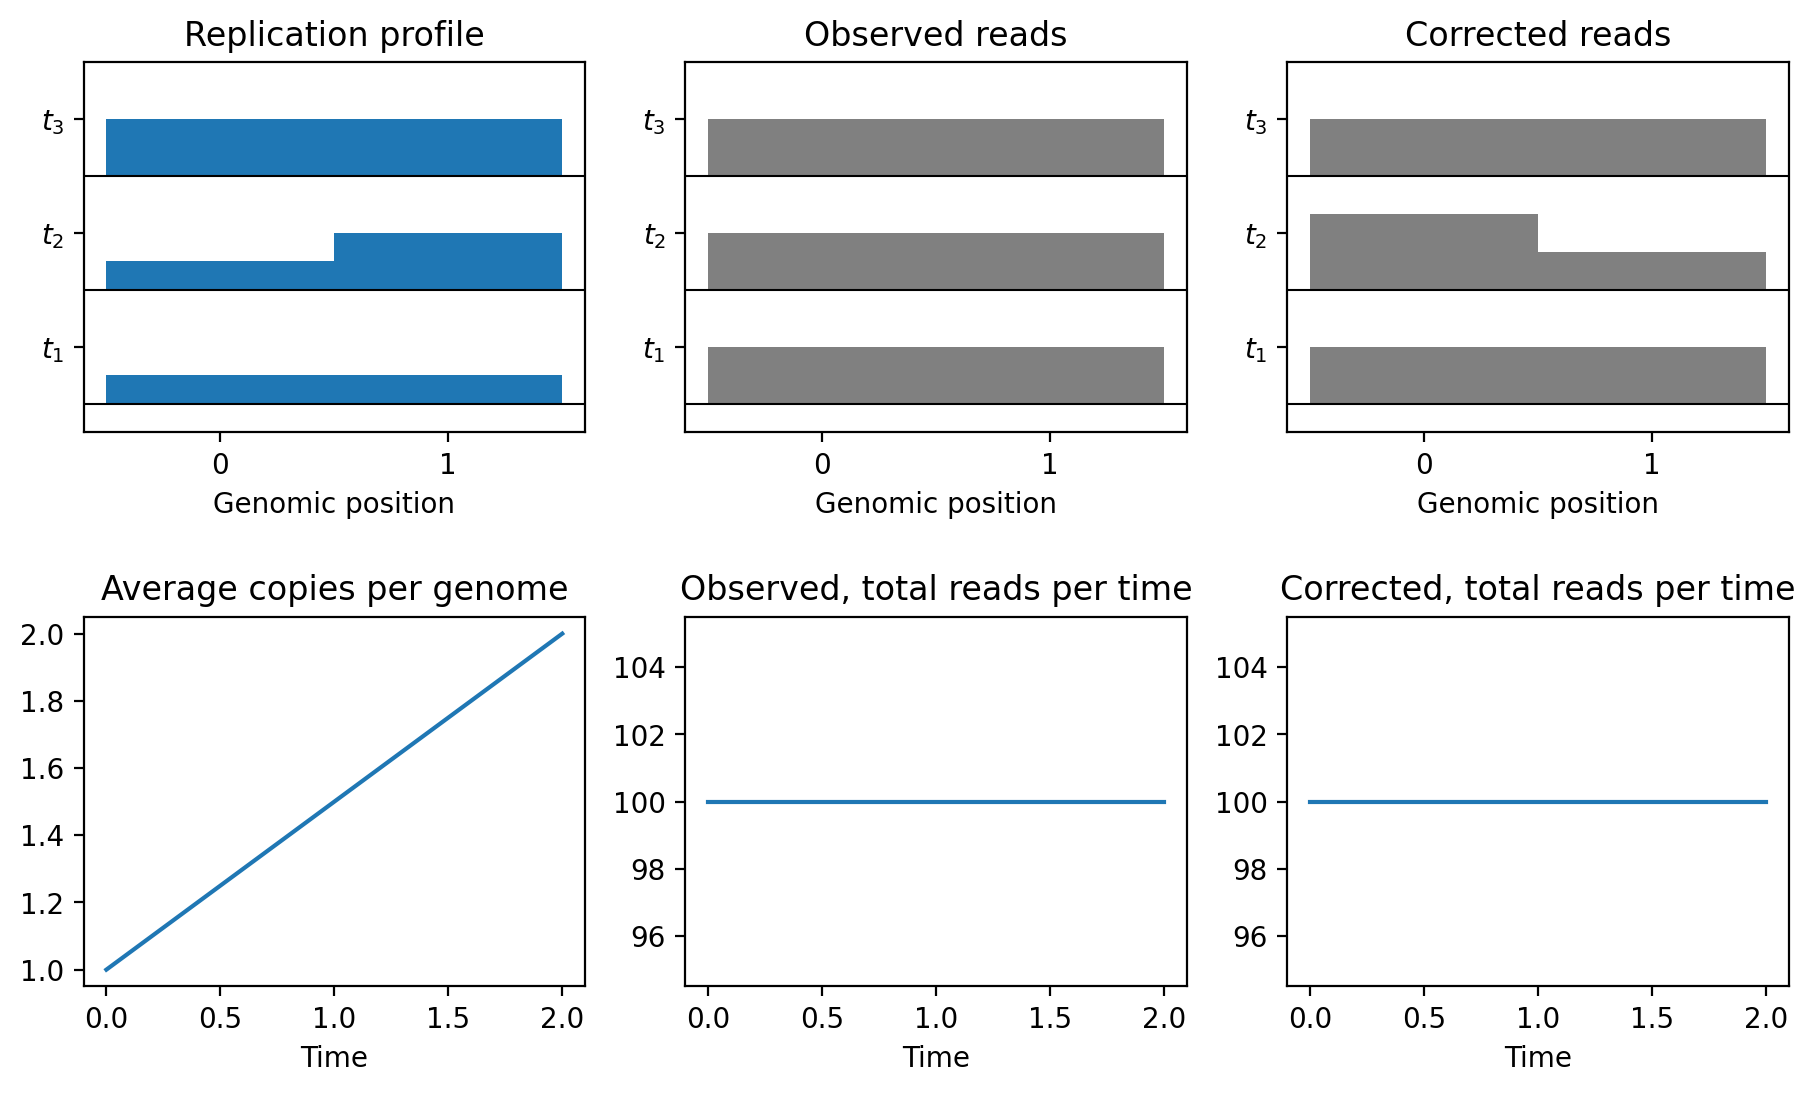

In [293]:
import numpy as np
from src.CopyNumberCorrection import correct_copy_number

# If we observe even reads across the time course
observed_reads = np.array([
    [100, 100],
    [100, 100],
    [100, 100]])

replication_profile_timecourse = np.array([
    [1, 1],
    [1, 2],
    [2, 2]],
)

from src.CopyNumberCorrection import CopyNumberCorrection

copy_corrector = CopyNumberCorrection(observed_reads, replication_profile_timecourse)
copy_corrector.plot_observed_vs_corrected()